In [1]:
import datasets

dataset = datasets.load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [3]:
dataset['train']['text'][12353]

'Hmmm...where to start? How does a serious actress like Demi Moore got involved in such crap? "First blood" might be rated as bull***t but this type of nonsense is just Rambo with tits, point. Of course if you are interested in the crapstory (Demi Moore just wants to prove that a woman can be part of the NAVY Seals) that is the most stupid cliché one I can think of, you\'ll say "GI Jane" is a great movie. Just the performance from Viggo Mortensen made this movie bearable but hell, I can\'t think of Demi Moore being Rambo (especially not during the last, useless, 30 minutes). Ridley Scott doesn\'t deserve the credits to make this movie one that comes up for women with equal rights, it\'s just brainless propaganda for the American army and to make it more attractive they dropped Moore in it. Awful movie.'

In [ ]:
dataset['train']['label'][12353]

0

In [5]:
from collections import Counter
counts = Counter(dataset['train']['label'])

counts

Counter({0: 12500, 1: 12500})

In [6]:
%pip install nltk
from IPython.display import clear_output
clear_output()

from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
print(word_tokenize(dataset['train']['text'][20000])[:100])

['After', 'reading', 'some', 'quite', 'negative', 'views', 'for', 'this', 'movie', ',', 'I', 'was', 'not', 'sure', 'whether', 'I', 'should', 'fork', 'out', 'some', 'money', 'to', 'rent', 'it', '.', 'However', ',', 'it', 'was', 'a', 'pleasant', 'surprise', '.', 'I', 'have', "n't", 'seen', 'the', 'original', 'movie', ',', 'but', 'if', 'its', 'better', 'than', 'this', ',', 'I', "'d", 'be', 'in', 'heaven.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'Tom', 'Cruise', 'gives', 'a', 'strong', 'performance', 'as', 'the', 'seemingly', 'unstable', 'David', ',', 'convincing', 'me', 'that', 'he', 'is', 'more', 'than', 'a', 'smile', 'on', 'legs', '(', 'for', 'only', 'the', 'third', 'time', 'in', 'his', 'career-', 'the', 'other', 'examples', 'were', 'Magnolia', 'and', 'Born']


In [ ]:
def split_tokens(row):
    row['tokens'] = word_tokenize(row['text'].lower())
    return row

In [9]:
dataset_train = dataset['train'].map(split_tokens)
dataset_train

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'tokens'],
    num_rows: 25000
})

In [10]:
dataset_train['tokens'][1]

['``',
 'i',
 'am',
 'curious',
 ':',
 'yellow',
 "''",
 'is',
 'a',
 'risible',
 'and',
 'pretentious',
 'steaming',
 'pile',
 '.',
 'it',
 'does',
 "n't",
 'matter',
 'what',
 'one',
 "'s",
 'political',
 'views',
 'are',
 'because',
 'this',
 'film',
 'can',
 'hardly',
 'be',
 'taken',
 'seriously',
 'on',
 'any',
 'level',
 '.',
 'as',
 'for',
 'the',
 'claim',
 'that',
 'frontal',
 'male',
 'nudity',
 'is',
 'an',
 'automatic',
 'nc-17',
 ',',
 'that',
 'is',
 "n't",
 'true',
 '.',
 'i',
 "'ve",
 'seen',
 'r-rated',
 'films',
 'with',
 'male',
 'nudity',
 '.',
 'granted',
 ',',
 'they',
 'only',
 'offer',
 'some',
 'fleeting',
 'views',
 ',',
 'but',
 'where',
 'are',
 'the',
 'r-rated',
 'films',
 'with',
 'gaping',
 'vulvas',
 'and',
 'flapping',
 'labia',
 '?',
 'nowhere',
 ',',
 'because',
 'they',
 'do',
 "n't",
 'exist',
 '.',
 'the',
 'same',
 'goes',
 'for',
 'those',
 'crappy',
 'cable',
 'shows',
 ':',
 'schlongs',
 'swinging',
 'in',
 'the',
 'breeze',
 'but',
 'not',
 

In [11]:
all_tokens = []

for tokens in dataset_train['tokens']:
  all_tokens.extend(tokens)

In [ ]:
len(all_tokens)

7063571

In [ ]:
token_counts = Counter(all_tokens)

token_counts.most_common(20)

[('the', 334840),
 (',', 275887),
 ('.', 234798),
 ('and', 163477),
 ('a', 162292),
 ('of', 145404),
 ('to', 135153),
 ('is', 110284),
 ('/', 102115),
 ('>', 102036),
 ('<', 101971),
 ('br', 101871),
 ('it', 95024),
 ('in', 93197),
 ('i', 86725),
 ('this', 75566),
 ('that', 73011),
 ("'s", 62167),
 ('was', 50383),
 ('as', 46834)]

In [14]:
token_counts_v2 = Counter([])

for tokens in dataset_train['tokens']:
    token_counts_v2.update(tokens)

token_counts_v2.most_common(20)

[('the', 334840),
 (',', 275887),
 ('.', 234798),
 ('and', 163477),
 ('a', 162292),
 ('of', 145404),
 ('to', 135153),
 ('is', 110284),
 ('/', 102115),
 ('>', 102036),
 ('<', 101971),
 ('br', 101871),
 ('it', 95024),
 ('in', 93197),
 ('i', 86725),
 ('this', 75566),
 ('that', 73011),
 ("'s", 62167),
 ('was', 50383),
 ('as', 46834)]

In [ ]:
print(len(token_counts_v2))

vocab = [token for token, count in token_counts_v2.items() if count >= 2]
print(len(vocab))
display(vocab[:10])

VOCAB_SIZE = len(vocab)

111827
56097


['i',
 'rented',
 'am',
 'curious-yellow',
 'from',
 'my',
 'video',
 'store',
 'because',
 'of']

In [ ]:
#vocab = ['<unk>'] + vocab # adicionando ruído pra teste?

# adicionar pad, precisamos de um id específico
vocab = ['<unk>', '<pad>'] + vocab

In [ ]:
token2id = {token: idx for idx, token in enumerate(vocab)}

In [18]:
display(token2id['of'])

display(token2id['<unk>'])

# display(token2id['naoexiste.com'])

11

0

In [ ]:
token2id.get('naoexiste.com', 0)

0

In [ ]:
def convert_tokens(tokens):
    result = []
    for token in tokens:
        result.append(token2id.get(token, 0))

    return result

In [21]:
print(dataset_train['tokens'][0])

['i', 'rented', 'i', 'am', 'curious-yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '1967.', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'u.s.', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', ',', 'therefore', 'being', 'a', 'fan', 'of', 'films', 'considered', '``', 'controversial', "''", 'i', 'really', 'had', 'to', 'see', 'this', 'for', 'myself.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything', 'she', 'can', 'about', 'life', '.', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her', 'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average', 'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam'

In [ ]:
print(convert_tokens(dataset_train['tokens'][0]))

[2, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 17, 19, 20, 21, 22, 23, 2, 24, 25, 15, 26, 20, 17, 19, 27, 28, 29, 30, 31, 17, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 11, 43, 44, 45, 46, 47, 2, 48, 49, 34, 50, 36, 51, 52, 53, 54, 55, 56, 53, 54, 55, 56, 13, 57, 58, 59, 60, 41, 61, 62, 63, 64, 65, 66, 67, 68, 34, 69, 70, 71, 72, 73, 74, 75, 22, 76, 71, 68, 34, 77, 78, 79, 34, 80, 81, 82, 11, 83, 84, 85, 13, 86, 87, 88, 73, 89, 90, 91, 92, 93, 13, 94, 95, 96, 97, 91, 22, 13, 98, 99, 75, 22, 100, 101, 102, 96, 103, 104, 11, 105, 73, 106, 107, 84, 108, 38, 71, 109, 110, 111, 78, 63, 112, 38, 113, 38, 96, 114, 115, 53, 54, 55, 56, 53, 54, 55, 56, 85, 116, 117, 73, 2, 4, 5, 58, 15, 118, 119, 120, 38, 36, 19, 44, 121, 75, 48, 38, 13, 110, 96, 122, 123, 124, 125, 96, 126, 100, 38, 127, 128, 17, 129, 130, 131, 132, 81, 133, 134, 135, 75, 136, 7, 137, 138, 139, 17, 140, 38, 22, 141, 110, 96, 122, 124, 41, 142, 143, 22, 62, 144, 75, 127, 145, 146, 38, 147, 106, 148, 34, 149, 1

In [ ]:
def tokens2ids(row):
    row['tokens_id'] = convert_tokens(row['tokens'])
    return row

In [24]:
dataset_train = dataset_train.map(tokens2ids)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
dataset_train

Dataset({
    features: ['text', 'label', 'tokens', 'tokens_id'],
    num_rows: 25000
})

In [ ]:
dataset_train['tokens_id'][1234]

[215,
 48,
 963,
 187,
 404,
 18545,
 166,
 36,
 162,
 4190,
 111,
 1145,
 11472,
 67,
 2014,
 34,
 6523,
 13,
 4477,
 1778,
 331,
 13,
 10865,
 14740,
 5863,
 18546,
 26,
 316,
 11,
 1636,
 5897,
 5557,
 11,
 5621,
 75,
 13,
 845,
 58,
 15,
 666,
 11472,
 2014,
 34,
 156,
 36,
 1809,
 119,
 390,
 106,
 4477,
 119,
 18,
 198,
 58,
 11956,
 34,
 824,
 506,
 13,
 1523,
 11,
 41,
 1551,
 18533,
 40,
 18547,
 34,
 172,
 13,
 1380,
 4448,
 18548,
 53,
 54,
 55,
 56,
 53,
 54,
 55,
 56,
 3823,
 58,
 15,
 78,
 1523,
 58,
 284,
 185,
 794,
 38,
 185,
 11,
 951,
 71,
 322,
 337,
 11,
 12,
 15,
 75,
 13,
 2973,
 567,
 1024,
 11397,
 18549,
 38,
 14299,
 3060,
 96,
 573,
 1940,
 18550,
 53,
 54,
 55,
 56,
 53,
 54,
 55,
 56,
 17,
 48,
 963,
 187,
 404,
 189,
 1554,
 166,
 36,
 594,
 162,
 75]

In [ ]:
vocab[214], vocab[67], vocab[5321]

('granted', 'who', 'choose')

In [28]:
import torch
from torch.utils.data import Dataset

# padding
MAX_SIZE = 500

class IMDBDataset(Dataset):
    def __init__(self, dataset):
        self.data = dataset['tokens_id'] # list[list[int]]
        self.labels = dataset['label']   # list[int] 0/1
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        x = torch.tensor(self.data[index], dtype=torch.long)
        y = torch.tensor(self.labels[index], dtype=torch.float32)
        return x, y

In [ ]:
my_dataset = IMDBDataset(dataset_train)

In [ ]:
len(my_dataset)

25000

In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """
    Função para processar batches com sequências de tamanhos diferentes.
    Aplica padding para que todas as sequências tenham o mesmo tamanho.
    """
    # Separar dados e labels
    sequences, labels = zip(*batch)

    # Aplicar padding às sequências (pad_id = 1, que é o token '<pad>')
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=1)

    # Converter labels para tensor
    labels_tensor = torch.stack(labels)

    return padded_sequences, labels_tensor

dataloader = DataLoader(my_dataset, shuffle=True, batch_size=2, collate_fn=collate_fn)

# batch size: defaulta pra 1, o que faz com que demore bastante
# collate_fn: pode ser um problema ter reviews de diferentes tamanhos, então precisamos de uma função de padding

In [32]:
for x, y in dataloader:
    print(x)
    print(y)
    break

tensor([[    2,    19,   315, 15900,    28,    13,   647,  4009,    26,    13,
          1867,    11,    13,   162,    15,     2,  1780,  5729,    34,     7,
          3613,    96,  2994,   327, 20915,    13,   384,   622,    75,   578,
           160,    72,  1614,    36,   162,   796,   166,    41,  1069,    11,
           349, 24494,   117,    75,     2,   854,    15,    13,  4859,    11,
            13,   384,    58,    34,   168,    38,   185,  2662,   677,  4009,
            11,    41,  2227,    15,    49,   372, 13592,  6420,   180,  5730,
           788,  9806,    93,     2,   302,   184,   415,  1160,   422,     2,
          4369,    17,   622,   390,    13,  1582,   111,    13, 26596,  2078,
            75,     2,    49,    49,     7,  1090,  2385,   358,    11,    13,
           335,   327,    34,    15,  2141,    75,   181,  1151,    36,   384,
            19,  1050,    26,    13,  1642,  6841,    22, 33540,    75,     2,
            48,   188,   181,  5623,    34,    50,  

In [46]:
from torch import nn

EMBED_LEN = 128
HIDDEN_DIM = 32
N_LAYERS = 1


class TextClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=EMBED_LEN)
        self.lstm = nn.LSTM(input_size=EMBED_LEN, hidden_size=HIDDEN_DIM, num_layers=N_LAYERS, batch_first=True)
        self.linear = nn.Linear(HIDDEN_DIM, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, input):
        embeddings = self.embedding_layer(input)
        output, (final_hidden, final_cell) = self.lstm(embeddings)

        #print('output ', output)
        #print('output shape ', output.shape)
#
        #print('final_hidden ', final_hidden)
        #print('final_hidden shape ', final_hidden.shape)
#
        #print('final_cell ', final_cell)
        #print('final_cell shape ', final_cell.shape)
        return self.sigmoid(self.linear(final_hidden[-1])).squeeze(1)

In [47]:
device = torch.device('cuda')

In [48]:
model = TextClassifier()
model = model.to(device)

In [49]:
LR = 1e-3
EPOCHS = 5
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [52]:
example = my_dataset[0][0].unsqueeze(0).to(device)
model(example)

tensor([0.4833], device='cuda:0', grad_fn=<SqueezeBackward1>)

In [53]:
from tqdm.notebook import tqdm

def train(dataloader, device):
    size = len(dataloader.dataset)
    train_loss = []

    for batch, (data, label) in enumerate(tqdm(dataloader)):
        data, label = data.to(device), label.to(device)

        out = model(data)
        loss = loss_fn(out.squeeze(), label.to(torch.float32))
        train_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 1000 == 0:
            loss, current = sum(train_loss)/len(train_loss), batch * len(data[1])
            print(f' loss: {loss:>7f} [{current:>5d}/{size:>5d}]')

    return sum(train_loss)/len(train_loss)

In [54]:
def test(dataloader, device):
    size = len(dataloader.dataset)
    test_loss = []
    correct = 0

    with torch.no_grad():       # não tem backpropagation no test, não precisamos rastrear o gradiente
        for data, label in tqdm(dataloader):
            data, label = data.to(device), label.to(device)
            out = model(data)

            loss = loss_fn(out.squeeze(), label.to(torch.float32))
            test_loss.append(loss.item())

            preds = (out.squeeze() > 0.5).int() # convertendo as probabilidades em 0 ou 1
            correct += (preds == label).sum().item()

    # test_loss /= size
    correct /= size
    print(f' test accuracy: {(100*correct):>0.1f}%, test loss: {sum(test_loss)/len(test_loss):>8f}')

    return sum(test_loss)/len(test_loss)

In [55]:
# my_dataset # train

dataset_test = dataset['test'].map(split_tokens)

In [56]:
dataset_test = dataset_test.map(tokens2ids) # não montamos vocabulario pro teste, ao inves disso,
                                          # usamos o token to id to treino, pra que fique com as mesmas representações

In [57]:
my_dataset_test = IMDBDataset(dataset_test)
dataloader_test = DataLoader(my_dataset_test, shuffle=True, batch_size=2, collate_fn=collate_fn)

In [58]:
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}\n------------")

    print('Train')
    train_losses.append(train(dataloader, device))

    print('Test')
    test_losses.append(test(dataloader, device))

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')

Epoch 1
------------
Train


  0%|          | 0/12500 [00:00<?, ?it/s]

 loss: 0.610493 [    0/25000]
 loss: 0.694400 [850000/25000]
 loss: 0.691233 [472000/25000]
 loss: 0.688763 [1260000/25000]
 loss: 0.685679 [608000/25000]
 loss: 0.681156 [700000/25000]
 loss: 0.674109 [1434000/25000]
 loss: 0.666817 [1372000/25000]
 loss: 0.661536 [5768000/25000]
 loss: 0.651989 [3087000/25000]
 loss: 0.644263 [4810000/25000]
 loss: 0.634267 [3047000/25000]
 loss: 0.625573 [4092000/25000]
Test


  0%|          | 0/12500 [00:00<?, ?it/s]

 test accuracy: 80.8%, test loss: 0.445807
Epoch 2
------------
Train


...

 test accuracy: 95.0%, test loss: 0.141998
Epoch 5
------------
Train


  0%|          | 0/12500 [00:00<?, ?it/s]

 loss: 1.647934 [    0/25000]
 loss: 0.134065 [645000/25000]
 loss: 0.140314 [1134000/25000]
 loss: 0.141462 [855000/25000]
 loss: 0.145870 [2168000/25000]
 loss: 0.150056 [1025000/25000]
 loss: 0.152705 [1614000/25000]
 loss: 0.156077 [3612000/25000]
 loss: 0.159472 [2080000/25000]
 loss: 0.160313 [2322000/25000]
 loss: 0.160305 [1350000/25000]
 loss: 0.161765 [1804000/25000]
 loss: 0.163436 [2100000/25000]
Test


  0%|          | 0/12500 [00:00<?, ?it/s]

 test accuracy: 96.9%, test loss: 0.101282


In [59]:
train_losses, test_losses

([0.6203602004572749,
  0.41666187504485247,
  0.30346800872519614,
  0.2173302623507008,
  0.1646656350268889],
 [0.44580674903959033,
  0.34061471559852363,
  0.24988986641071737,
  0.14199780133355408,
  0.10128201766727492])

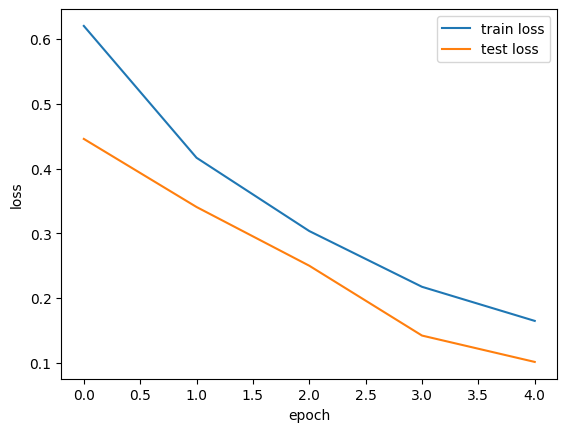

In [60]:
# plottagem do grafico de treino
import matplotlib.pyplot as plt
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

# save the model to my drive
torch.save(model.state_dict(), '/content/drive/MyDrive/lstm_10_02_26_model_epoch_final.pth')
# download from drive to my computer

files.download('/content/drive/MyDrive/lstm_10_02_26_model_epoch_final.pth')

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# exemplo de inferencia
negative_review = "This movie was terrible. I hated it and would not recommend it to anyone."
positive_review = "This movie was fantastic! I loved it and would highly recommend it to everyone."

tokenized_negative_review = word_tokenize(negative_review.lower())
tokenized_positive_review = word_tokenize(positive_review.lower())
tokenized_negative_review_ids = convert_tokens(tokenized_negative_review)
tokenized_positive_review_ids = convert_tokens(tokenized_positive_review)

input_negative = torch.tensor(tokenized_negative_review_ids, dtype=torch.long).unsqueeze(1).to(device)
input_positive = torch.tensor(tokenized_positive_review_ids, dtype=torch.long).unsqueeze(1).to(device)

model.eval()

with torch.no_grad():
    output_negative = model(input_negative)
    output_positive = model(input_positive)

print(f"Negative review prediction: {output_negative.item():.4f} (0 = negative, 1 = positive)")
print(f"Positive review prediction: {output_positive.item():.4f} (0 = negative, 1 = positive)")

Negative review prediction: 0.0104 (0 = negative, 1 = positive)
Positive review prediction: 0.9998 (0 = negative, 1 = positive)
